![](./Prints%20das%20questões/6.png)

# Solução — Questão 6

## Enunciado (resumo)

Para a planta do exercício anterior,

$$G(s)=\frac{4}{(s+1)(s+3)(s+4)},$$

projetar um controlador **PI** pelo método de sintonia de **Ziegler-Nichols em malha fechada**.

---

## Método de Ziegler-Nichols (malha fechada)

1. Fechar a malha apenas com controlador **proporcional** $C(s)=K_p$.
2. Aumentar $K_p$ até a resposta apresentar **oscilações sustentadas** (margem de estabilidade).
3. Registrar o **ganho crítico** $K_u$ e o **período crítico** $P_u$ das oscilações.
4. Calcular os parâmetros do **PI**:

$$K_p = 0{,}45\,K_u, \qquad T_i = \frac{P_u}{1{,}2}, \qquad K_i = \frac{K_p}{T_i} = 0{,}54\,\frac{K_u}{P_u}.$$

---

## Determinação de $K_u$ e $P_u$

Com $C(s)=K$, a equação característica é

$$s^3 + 8s^2 + 19s + (12 + 4K) = 0.$$

Pelo **critério de Routh-Hurwitz**, oscilações sustentadas ocorrem quando

$$8 \cdot 19 - 1 \cdot (12 + 4K_u) = 0 \quad \Rightarrow \quad K_u = 35.$$

Substituindo $K_u$ e $s=j\omega_u$ na equação característica:

$$-\,j\omega_u^3 - 8\omega_u^2 + 19j\omega_u + 52 = 0.$$

Da parte imaginária: $\omega_u^2 = 19$, logo $\omega_u = \sqrt{19}\,\mathrm{rad/s}$ e

$$P_u = \frac{2\pi}{\omega_u} \approx 1{,}44\,\mathrm{s}.$$

---

## Controlador PI projetado

$$K_p = 0{,}45 \times 35 = 15{,}75, \qquad T_i = \frac{1{,}44}{1{,}2} \approx 1{,}20\,\mathrm{s}, \qquad K_i = \frac{15{,}75}{1{,}20} \approx 13{,}11.$$

Logo,

$$C(s) = 15{,}75 + \frac{13{,}11}{s} = \frac{15{,}75\,s + 13{,}11}{s}.$$

A verificação numérica (biblioteca `control`) confirma os resultados nos gráficos abaixo.

SINTONIA ZIEGLER-NICHOLS — MALHA FECHADA
Ganho crítico Ku        : 35.00
Frequência crítica ωu   : 4.3589 rad/s
Período crítico Pu      : 1.4415 s
------------------------------------------------------------------------
Kp (PI)                 : 15.75
Ki (PI)                 : 13.1117
Ti (PI)                 : 1.2012 s
C(s)                    : 15.75 + 13.11/s
------------------------------------------------------------------------
Polos com K=Ku (P)      : [-8.0000000e+00+0.j          3.1918912e-16-4.35889894j
  3.1918912e-16+4.35889894j]
Polos com PI (ZN)       : [-6.66048757+0.j         -0.81590809+0.j         -0.26180217-3.09555176j
 -0.26180217+3.09555176j]
Ganho DC (malha fechada): 1.000000
Erro estacionário degrau: 0.00e+00
RiseTime                : 0.4145 s
SettlingTime            : 14.4881 s
Sobressinal             : 66.942 %


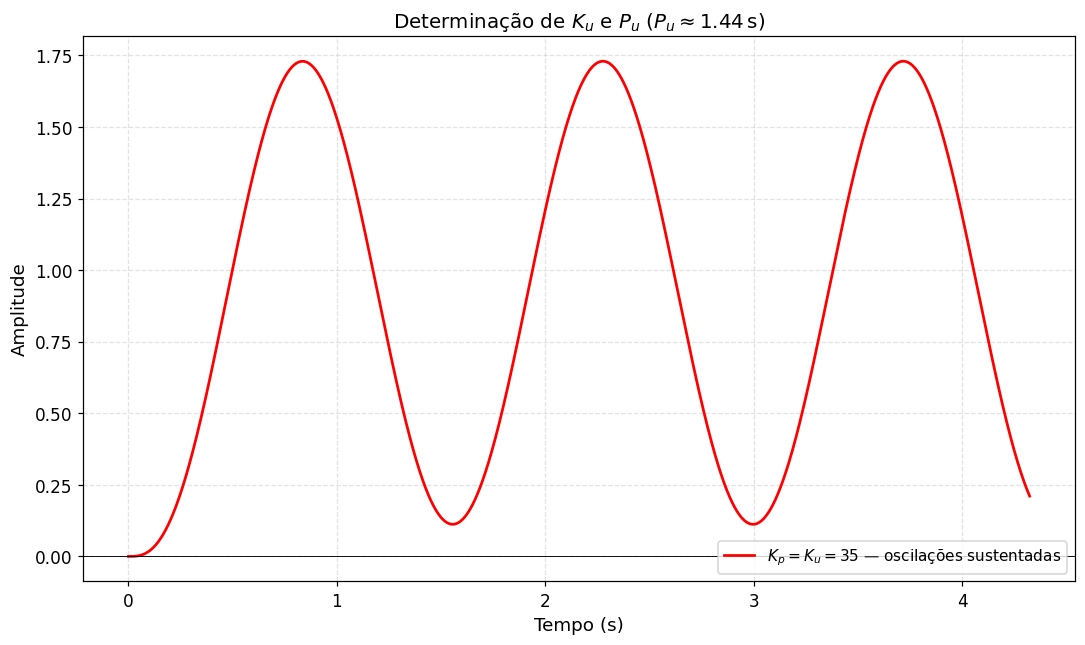

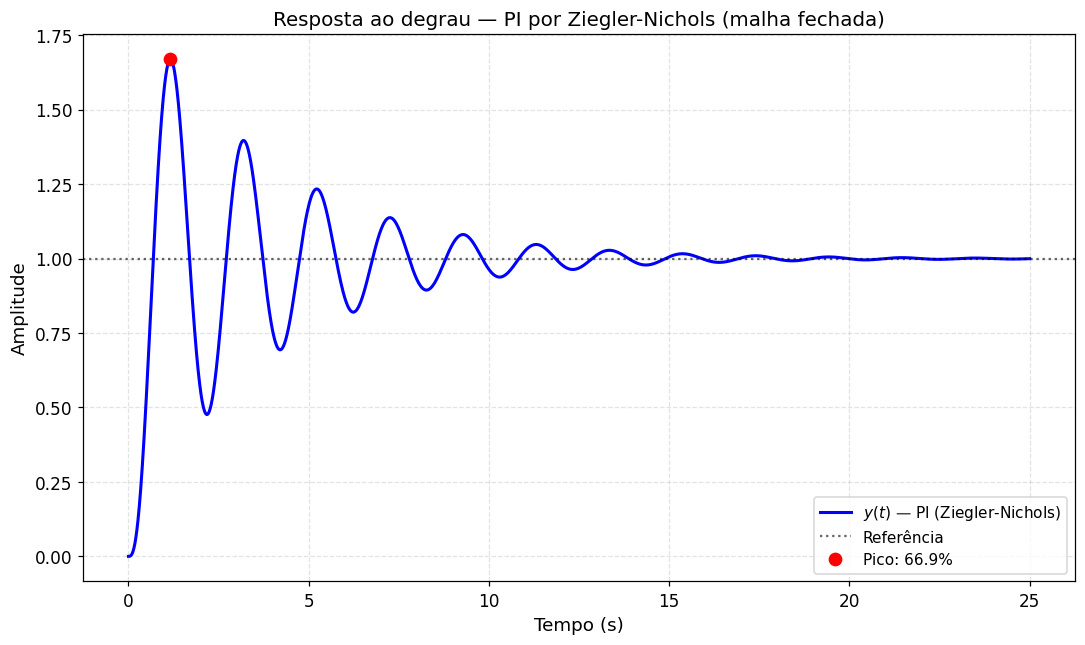

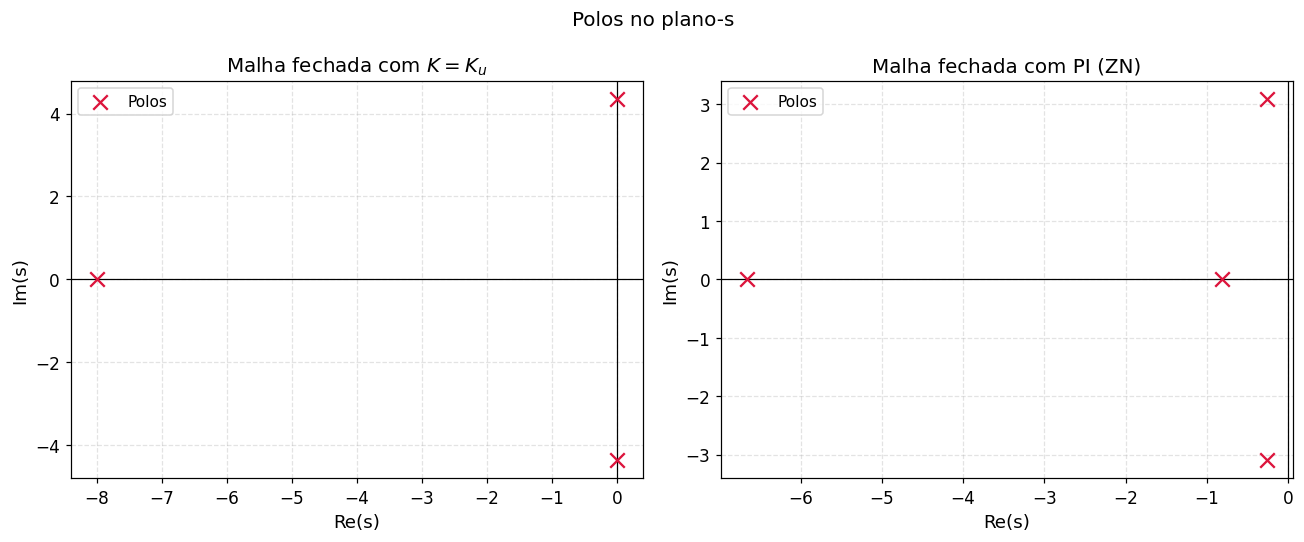

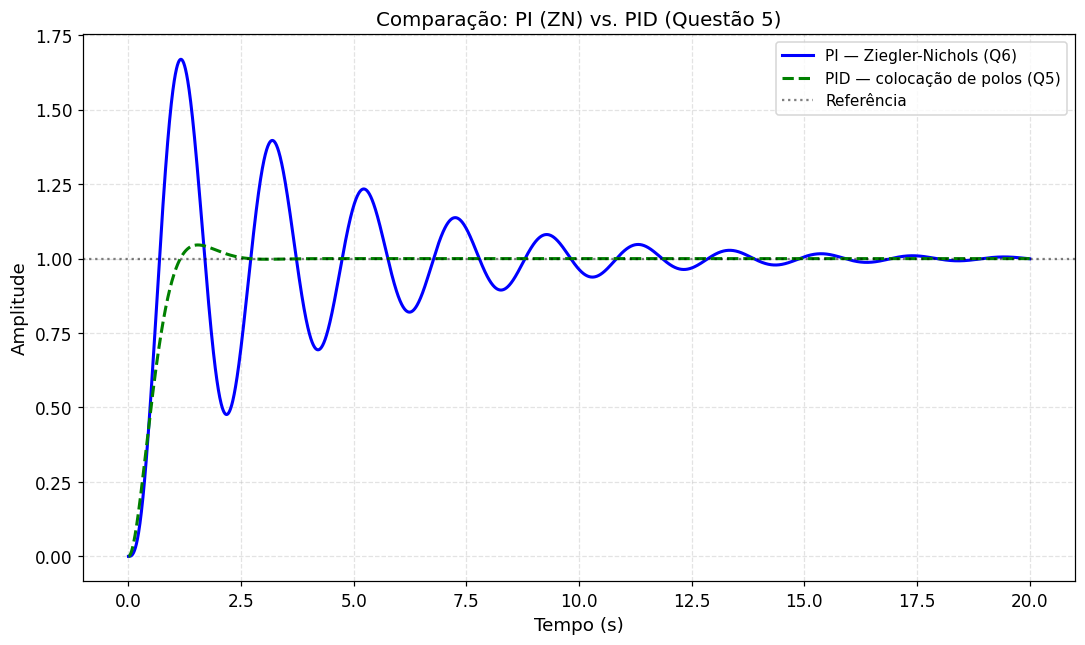

In [1]:
"""
Questão 6 — Sintonia PI por Ziegler-Nichols (malha fechada).
Planta: G(s) = 4/((s+1)(s+3)(s+4)), realimentação unitária.
"""

from __future__ import annotations

import warnings

import control as ct
import matplotlib.pyplot as plt
import numpy as np

warnings.filterwarnings("ignore", category=FutureWarning, module=r"control\.rlocus")

plt.rcParams.update(
    {
        "figure.figsize": (10, 6),
        "figure.dpi": 110,
        "font.size": 11,
        "axes.grid": True,
        "grid.linestyle": "--",
        "grid.alpha": 0.35,
        "axes.labelsize": 12,
        "axes.titlesize": 13,
        "legend.fontsize": 10,
    }
)

KU = 35.0
OMEGA_U = np.sqrt(19.0)
PU = 2 * np.pi / OMEGA_U
KP_PI = 0.45 * KU
TI = PU / 1.2
KI = 0.54 * KU / PU


def planta() -> ct.TransferFunction:
    """G(s) = 4/((s+1)(s+3)(s+4))."""
    s = ct.tf("s")
    return 4 / ((s + 1) * (s + 3) * (s + 4))


def controlador_pi() -> ct.TransferFunction:
    """C(s) = Kp + Ki/s — PI por Ziegler-Nichols (malha fechada)."""
    s = ct.tf("s")
    return KP_PI + KI / s


def malha_proporcional(kp: float) -> ct.TransferFunction:
    """Malha fechada com controlador proporcional C(s)=kp."""
    return ct.feedback(kp * planta(), 1)


def malha_pi() -> ct.TransferFunction:
    """Malha fechada com controlador PI sintonizado."""
    return ct.feedback(controlador_pi() * planta(), 1)


def imprimir_relatorio() -> None:
    """Exibe parâmetros ZN e indicadores da resposta ao degrau."""
    sys_crit = malha_proporcional(KU)
    sys_pi = malha_pi()
    polos_crit = ct.poles(sys_crit)
    polos_pi = ct.poles(sys_pi)
    info = ct.step_info(sys_pi)

    sep = "=" * 72
    print(sep)
    print("SINTONIA ZIEGLER-NICHOLS — MALHA FECHADA")
    print(sep)
    print(f"Ganho crítico Ku        : {KU:.2f}")
    print(f"Frequência crítica ωu   : {OMEGA_U:.4f} rad/s")
    print(f"Período crítico Pu      : {PU:.4f} s")
    print("-" * 72)
    print(f"Kp (PI)                 : {KP_PI:.2f}")
    print(f"Ki (PI)                 : {KI:.4f}")
    print(f"Ti (PI)                 : {TI:.4f} s")
    print(f"C(s)                    : {KP_PI:.2f} + {KI:.2f}/s")
    print("-" * 72)
    print(f"Polos com K=Ku (P)      : {np.sort(polos_crit)}")
    print(f"Polos com PI (ZN)       : {np.sort(polos_pi)}")
    print(f"Ganho DC (malha fechada): {ct.dcgain(sys_pi):.6f}")
    print(f"Erro estacionário degrau: {1 - ct.dcgain(sys_pi):.2e}")
    print(f"RiseTime                : {info['RiseTime']:.4f} s")
    print(f"SettlingTime            : {info['SettlingTime']:.4f} s")
    print(f"Sobressinal             : {info['Overshoot']:.3f} %")
    print(sep)


def plotar_oscilacao_critica() -> None:
    """Resposta ao degrau com K=Ku — oscilações sustentadas."""
    sys_crit = malha_proporcional(KU)
    t = np.linspace(0, 3 * PU, 3000)
    tout, yout = ct.step_response(sys_crit, T=t)

    fig, ax = plt.subplots()
    ax.plot(tout, yout, "r", linewidth=1.8,
            label=rf"$K_p=K_u={KU:.0f}$ — oscilações sustentadas")
    ax.axhline(0, color="k", linewidth=0.6)
    ax.set_xlabel("Tempo (s)")
    ax.set_ylabel("Amplitude")
    ax.set_title(rf"Determinação de $K_u$ e $P_u$ ($P_u \approx {PU:.2f}\,\mathrm{{s}}$)")
    ax.legend()
    fig.tight_layout()


def plotar_resposta_pi() -> None:
    """Resposta ao degrau com controlador PI sintonizado."""
    sys_pi = malha_pi()
    t = np.linspace(0, 25, 4000)
    tout, yout = ct.step_response(sys_pi, t)
    info = ct.step_info(sys_pi)

    fig, ax = plt.subplots()
    ax.plot(tout, yout, "b", linewidth=2, label=r"$y(t)$ — PI (Ziegler-Nichols)")
    ax.axhline(1.0, color="k", linestyle=":", alpha=0.6, label="Referência")
    if info["Overshoot"] > 0.5:
        ax.plot(info["PeakTime"], info["Peak"], "ro", markersize=8,
                label=rf"Pico: {info['Overshoot']:.1f}%")
    ax.set_xlabel("Tempo (s)")
    ax.set_ylabel("Amplitude")
    ax.set_title("Resposta ao degrau — PI por Ziegler-Nichols (malha fechada)")
    ax.legend(loc="lower right")
    fig.tight_layout()


def plotar_polos_zeros() -> None:
    """Polos em malha fechada: ganho crítico vs. PI."""
    polos_crit = ct.poles(malha_proporcional(KU))
    polos_pi = ct.poles(malha_pi())

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, polos, titulo in zip(
        axes,
        [polos_crit, polos_pi],
        [rf"Malha fechada com $K=K_u$", "Malha fechada com PI (ZN)"],
    ):
        ax.scatter(np.real(polos), np.imag(polos), marker="x", s=90,
                   color="crimson", label="Polos", zorder=3)
        ax.axvline(0, color="k", linewidth=0.8)
        ax.axhline(0, color="k", linewidth=0.8)
        ax.set_xlabel("Re(s)")
        ax.set_ylabel("Im(s)")
        ax.set_title(titulo)
        ax.legend()

    fig.suptitle("Polos no plano-s", fontsize=13)
    fig.tight_layout()


def plotar_comparacao_pid_questao5() -> None:
    """Compara PI (ZN) com o PID da Questão 5."""
    s = ct.tf("s")
    c_pid = (2.04 * s**2 + 8.16 * s + 6.12) / s
    sys_pid = ct.feedback(c_pid * planta(), 1)
    sys_pi = malha_pi()

    t = np.linspace(0, 20, 4000)
    _, y_pi = ct.step_response(sys_pi, t)
    _, y_pid = ct.step_response(sys_pid, t)

    fig, ax = plt.subplots()
    ax.plot(t, y_pi, "b", linewidth=2, label="PI — Ziegler-Nichols (Q6)")
    ax.plot(t, y_pid, "g--", linewidth=2, label="PID — colocação de polos (Q5)")
    ax.axhline(1.0, color="k", linestyle=":", alpha=0.5, label="Referência")
    ax.set_xlabel("Tempo (s)")
    ax.set_ylabel("Amplitude")
    ax.set_title("Comparação: PI (ZN) vs. PID (Questão 5)")
    ax.legend()
    fig.tight_layout()


# ---------------------------------------------------------------------------
# Execução
# ---------------------------------------------------------------------------

imprimir_relatorio()
plotar_oscilacao_critica()
plotar_resposta_pi()
plotar_polos_zeros()
plotar_comparacao_pid_questao5()
plt.show()

## Interpretação dos gráficos

### Oscilações sustentadas ($K_u$)
- Com $K_p = K_u = 35$, a malha fechada torna-se **marginalmente estável**: os polos complexos estão sobre o eixo imaginário em $s = \pm j\sqrt{19}$.
- A resposta ao degrau apresenta oscilação **não amortecida**, permitindo medir $P_u = 2\pi/\omega_u \approx 1{,}44\,\mathrm{s}$.
- Esse é o passo fundamental do método de Ziegler-Nichols em malha fechada.

### Resposta ao degrau (PI)
- O controlador PI converge para **1** → **erro estacionário nulo** (integrador presente).
- A resposta é **subamortecida** com **alto sobressinal** (~67%) — comportamento típico do ZN, que prioriza rapidez em detrimento do amortecimento.
- O tempo de acomodação é **maior** que o especificado na Questão 5, pois o ZN não impõe $\zeta$ nem $T_s$ diretamente.

### Polos no plano-s
- Com $K_u$: par complexo sobre o eixo $j\omega$ + polo real em $s=-8$.
- Com PI (ZN): todos os polos migram para o semiplano esquerdo, mas o par dominante permanece **próximo do eixo imaginário** → explica o alto sobressinal.

### Comparação com Questão 5
- O **PID por colocação de polos** (Q5) atende $\zeta=0{,}7$ e $T_s\approx 1{,}5\,\mathrm{s}$ com sobressinal moderado (~5%).
- O **PI por Ziegler-Nichols** (Q6) é mais simples de sintonizar (apenas $K_u$ e $P_u$), porém produz resposta mais **oscilatória** e **lenta** para essa planta.
- O ZN é adequado como ponto de partida; para requisitos transitórios rígidos, métodos analíticos (Q5) são preferíveis.